In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Fijamos semilla para reproducibilidad
np.random.seed(10)

# Generamos datos base
x0 = np.random.randn(750, 2)
mediax = np.array([35, 20])

## Casos de Simulación de Datos

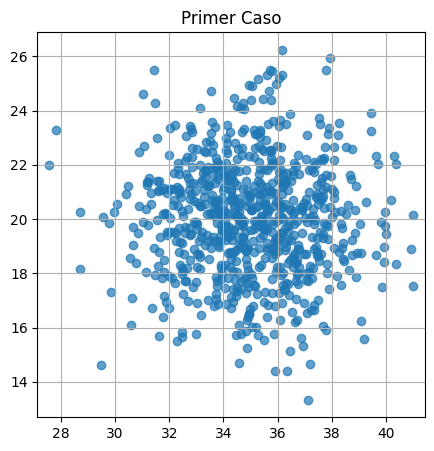

In [3]:
# Primer Caso
x = x0.copy()
covx = np.array([[5, 0], [0, 5]])
x = x @ np.linalg.cholesky(covx).T + mediax

plt.figure(figsize=(5, 5))
plt.scatter(x[:, 0], x[:, 1], alpha=0.7)
plt.title('Primer Caso')
plt.axis('equal')
plt.grid(True)
plt.show()

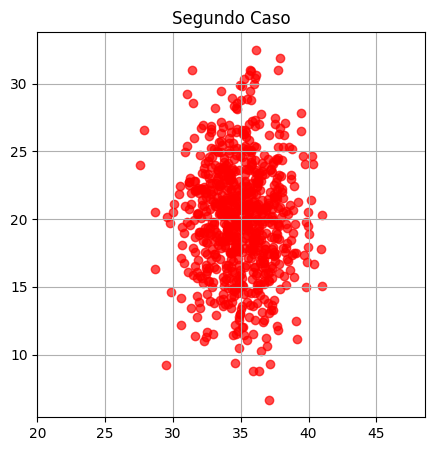

In [4]:
# Segundo Caso
x = x0.copy()
covx = np.array([[5, 0], [0, 20]])
x = x @ np.linalg.cholesky(covx).T + mediax

plt.figure(figsize=(5, 5))
plt.scatter(x[:, 0], x[:, 1], color='red', alpha=0.7)
plt.title('Segundo Caso')
plt.axis('equal')
plt.grid(True)
plt.show()

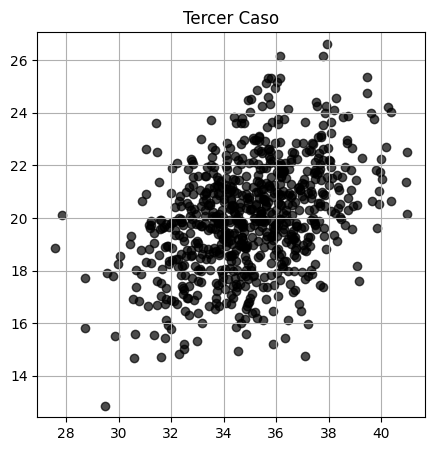

In [5]:
# Tercer Caso
x = x0.copy()
covx = np.array([[5, 2], [2, 5]])
x = x @ np.linalg.cholesky(covx).T + mediax

plt.figure(figsize=(5, 5))
plt.scatter(x[:, 0], x[:, 1], color='black', alpha=0.7)
plt.title('Tercer Caso')
plt.axis('equal')
plt.grid(True)
plt.show()

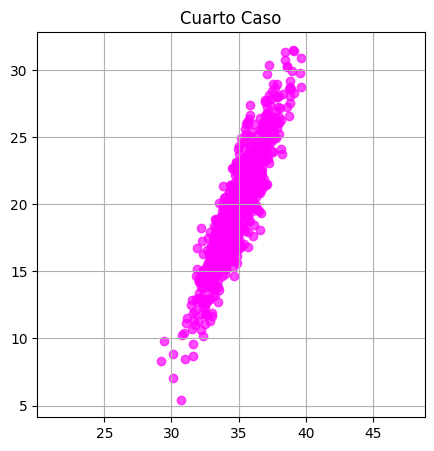

In [6]:
# Cuarto Caso
x = x0.copy()
covx = np.array([[3, 7], [7, 20]])
x = x @ np.linalg.cholesky(covx).T + mediax

plt.figure(figsize=(5, 5))
plt.scatter(x[:, 0], x[:, 1], color='magenta', alpha=0.7)
plt.title('Cuarto Caso')
plt.axis('equal')
plt.grid(True)
plt.show()

## ACP paso a paso

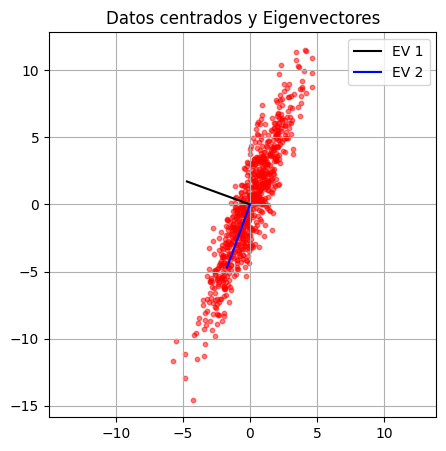

In [7]:
# 1. Quitar la media
media = np.mean(x, axis=0)
x_sm = x - media

# 2. Calcular matriz de covarianza
covarianza = np.cov(x_sm, rowvar=False)

# 3. Eigenvalores y eigenvectores
L_vals, Q = np.linalg.eig(covarianza)
L = np.diag(L_vals)

# Graficar
plt.figure(figsize=(5, 5))
plt.scatter(x_sm[:, 0], x_sm[:, 1], color='red', s=10, alpha=0.5)
plt.plot([0, Q[0, 0] * 5], [0, Q[1, 0] * 5], color='black', label='EV 1')
plt.plot([0, Q[0, 1] * 5], [0, Q[1, 1] * 5], color='blue', label='EV 2')
plt.title('Datos centrados y Eigenvectores')
plt.axis('equal')
plt.legend()
plt.grid(True)
plt.show()

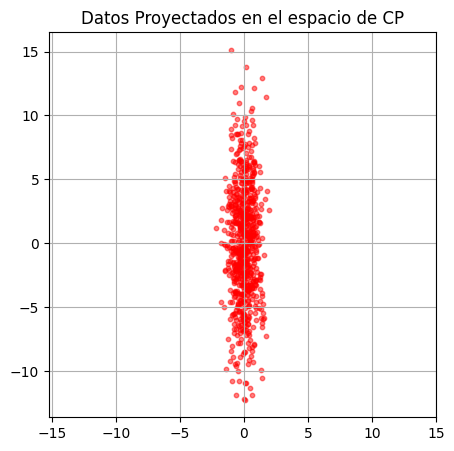

In [8]:
# 4. Proyección de datos
x_cp = x_sm @ Q

plt.figure(figsize=(5, 5))
plt.scatter(x_cp[:, 0], x_cp[:, 1], color='red', s=10, alpha=0.5)
plt.title('Datos Proyectados en el espacio de CP')
plt.axis('equal')
plt.grid(True)
plt.show()

In [9]:
Q[0, :]

array([-0.93967029, -0.34208148])

## PCA con funciones nativas de Python

In [10]:
from sklearn.decomposition import PCA

Matriz de covarianza (estimada por PCA):
[[ 2.83178762  6.55561228]
 [ 6.55561228 18.45299443]]

Eigenvectores (Componentes principales - Filas de la matriz):
[[ 0.34208148  0.93967029]
 [ 0.93967029 -0.34208148]]

Varianza explicada por cada componente (Eigenvalores):
[20.8395268   0.44525526]


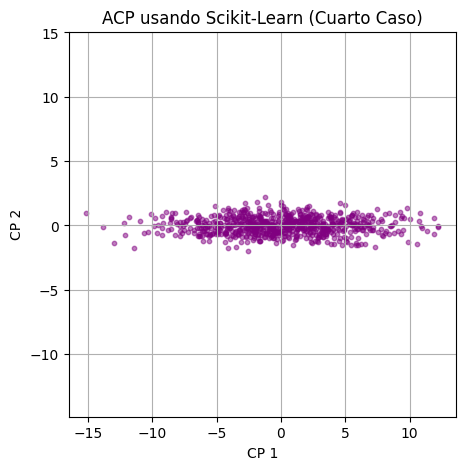

In [11]:
x = x0.copy()
covx = np.array([[3, 7], [7, 20]])
x = x @ np.linalg.cholesky(covx).T + mediax

# 1. Instanciamos el modelo PCA
# 'n_components=2' porque queremos mantener las dos dimensiones para la proyección
pca = PCA(n_components=2)

# 2. Ajustamos el modelo y transformamos los datos (Proyección)
# Esto centra los datos y los proyecta en el espacio de CP en un solo paso
x_cp_sklearn = pca.fit_transform(x)

# 3. Extraemos los resultados clave para comparar ambas implementaciones
print("Matriz de covarianza (estimada por PCA):")
print(pca.get_covariance())

print("\nEigenvectores (Componentes principales - Filas de la matriz):")
print(pca.components_)

print("\nVarianza explicada por cada componente (Eigenvalores):")
print(pca.explained_variance_)

# --- VISUALIZACIÓN ---
plt.figure(figsize=(5, 5))
# Graficamos los datos ya proyectados en el espacio de componentes principales
plt.scatter(x_cp_sklearn[:, 0], x_cp_sklearn[:, 1], color='purple', s=10, alpha=0.5)

plt.xlabel('CP 1')
plt.ylabel('CP 2')
plt.title('ACP usando Scikit-Learn (Cuarto Caso)')
plt.axis('equal')
plt.grid(True)
plt.show()